## Long-Short Strategy Using MLFactor Data

In this project you will use the MLFactor data to formulate a long-short, dollar-neutral, trading strategy that you will backtest.

Your strategy will be informed by the inferences of one several machine learning models.  The positions in the trading strategy will be rebalanced each month.  The models will be refit at each rebalancing using some amount of the most recent historical data.  The totality of the data is from 2000-2018.  The backtest period will be the 11 years from 2008-2018.

**NOTE:** By definition a dollar-neutral strategy is one in which the weights sum to zero.  Let's also constrain the weights to be between -1 and 1.

**Coding and Analysis (Jupyter Notebooks) -- 200 pts**

1. Using data from 2000-2007, select 30-40 features using the framework in this article: https://www.kaggle.com/code/sgalella/correlation-heatmaps-with-hierarchical-clustering.  This will have the effect of removing highly correlated (hence redundant) features.  These will be the features that you use throughout the rest of the project.

3. Use the following models:

    - `LinearRegression`
    - Dense Feed-Forward Neural Network Regression
    - Dense Feed-Forward Neural Network Classification

**Warning:** There are two different lables: `R1M_Usd` for regression and `R1M_Usd_C` for classification.  Be sure not to use the regression label as a *feature* for the classification formulation, and vice-versa.

2. Do analysis to determine if your feature selection process is improving model performance.

3. With the Neural Network models, experiment with:

    - different architectures (hidden layers and hidden units)
    - regularization
    - number of epochs and batch sizes

4. Experiment with different look-back windows of historical data to use at each refitting/rebalancing.

5. Devise your own benchmark strategy and defend why your strategy makes sense. 

6. Use a variety of investment performance metrics to compare the different approaches to formulating the strategy; be sure to include correlation to the equally weighted market portfolio.

7. Make a final conclusion about the strategy specification, including which model and architecture that you would use.

**Grading Rubric:**
- accuracy of results: 100 pts
- code commenting: 50 pts
- readability of notebook: 50 pts

**Wrtten Report -- 25 pts**

1. This will be a Quarto html document, and should include visualizations that are the output of code cells.  Keep your code cells folded so they don't clutter up the report.

2. Treat it like a professional document rather than an academic document.

3. Discuss the different achitectures you tried and describe their impact on your strategy.

4. Describe your trading/investment strategy and how it is informed by your predictive models; also describe your benchmark.
    
5. Present the results of your backtest results.
    - Which model you use to trade your strategy?
    - How did your models perform again your benchmark?
    - Did feature selection seem to help?
    - Do you notice any relationship between your training cross-validation fit scores and strategy performance on the test set?

**Presentation -- 75 pts**

1. Create a slide presentation.

2. Give a comparative analysis of the various strategy specifications you tried, and also present the performance of your benchmark.

3. Give your conclusion as to which strategy specification you would ultimately use.

Your presentation should be 10-15 minutes and include visualizations.

In [219]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

### Loading dataset

In [220]:
data = pd.read_csv("mlfactor_long_short.csv")
data['date'] = pd.to_datetime(data['date'])
data.shape

(268479, 97)

In [221]:
data["date"].dt.year.unique()

array([2006, 2007, 2015, 2016, 2017, 2002, 2003, 2004, 2005, 2000, 2001,
       2018, 2013, 2014, 2008, 2009, 2010, 2011, 2012, 1999], dtype=int32)

In [222]:
data = data.sort_values(by=['date']).reset_index(drop=True)

### Filtering data for year <= 2007

In [223]:
## Filtering data for year <= 2007
data_train = data[data['date'].dt.year <= 2007]
data_train.shape

(113304, 97)

In [224]:
## Removing categorical and target variables
data_train = data_train.drop(["stock_id", 'date', 'R1M_Usd', 'R1M_Usd_C'], axis=1)
data_train.head()

,Advt_12M_Usd,Advt_3M_Usd,Advt_6M_Usd,Asset_Turnover,Bb_Yld,Bv,Capex_Ps_Cf,Capex_Sales,Cash_Div_Cf,Cash_Per_Share,...,Share_Turn_6M,Ta,Tev_Less_Mktcap,Tot_Debt_Rev,Total_Capital,Total_Debt,Total_Debt_Capital,Total_Liabilities_Total_Assets,Vol1Y_Usd,Vol3Y_Usd
0,0.72,0.71,0.71,0.08,0.65,0.86,0.27,0.19,0.75,0.96,...,0.12,0.97,0.97,0.96,0.95,0.98,0.95,0.95,0.14,0.50
1,0.27,0.25,0.30,0.92,0.35,0.20,0.17,0.26,0.20,0.24,...,0.78,0.20,0.38,0.29,0.20,0.30,0.48,0.52,0.71,0.66
2,0.95,0.97,0.95,0.38,0.71,0.52,0.09,0.34,0.24,0.77,...,0.97,0.41,0.03,0.76,0.50,0.51,0.51,0.36,0.83,0.82
3,0.41,0.40,0.38,0.79,0.13,0.57,0.70,0.20,0.71,0.77,...,0.51,0.55,0.56,0.40,0.56,0.59,0.56,0.61,0.43,0.35
4,0.60,0.67,0.66,0.47,0.31,0.69,0.83,0.87,0.68,0.14,...,0.56,0.63,0.49,0.46,0.64,0.58,0.38,0.48,0.16,0.12


In [225]:
## Normalizing the data
scaler = StandardScaler()
data_train = pd.DataFrame(scaler.fit_transform(data_train), columns=data_train.columns)

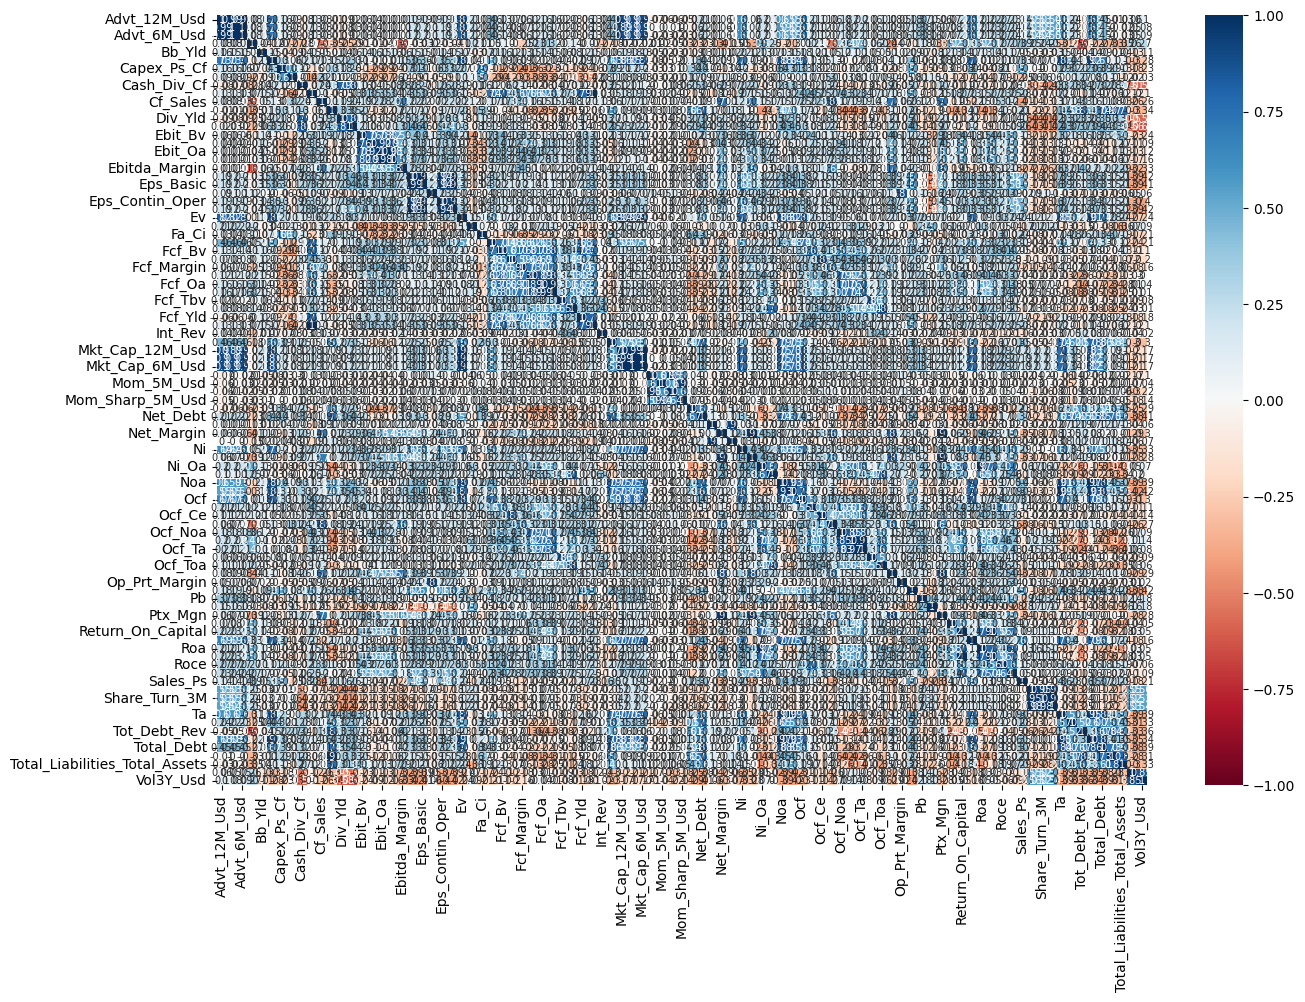

In [226]:
## Compute the correlation matrix
plt.figure(figsize=(15,10))
correlations = data_train.corr()
sns.heatmap(round(correlations,2), cmap='RdBu', annot=True, 
            annot_kws={"size": 7}, vmin=-1, vmax=1);

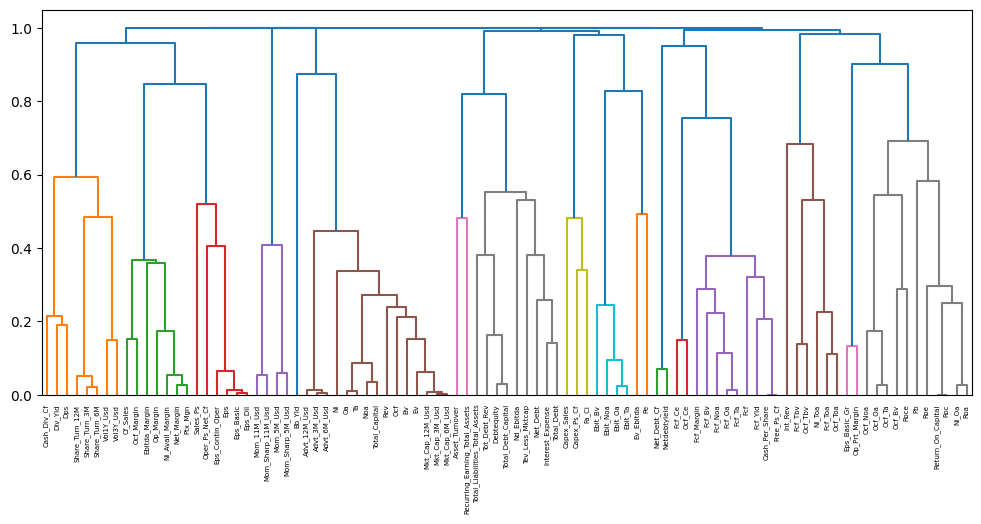

In [227]:
## Hierarchical Clustering
plt.figure(figsize=(12,5))
dissimilarity = 1 - abs(correlations)
Z = linkage(squareform(dissimilarity), 'complete')

dendrogram(Z, labels=data_train.columns, orientation='top', 
           leaf_rotation=90);

### Choosing threshold = 0.38 for clustering, to get the variable clusters ~35

In [228]:
# Clusterize the data
threshold = 0.38
labels = fcluster(Z, threshold, criterion='distance')

# Show the cluster (IDs) assignment for each feature
labels

array([10, 10, 10, 13, 12, 11, 20, 21,  1, 27,  4, 15,  1,  1, 22, 22, 22,
       22,  4,  5,  5, 31,  5,  5, 11, 23, 20, 27, 27, 26, 27, 27, 27, 27,
       28, 29, 27, 27, 30, 17, 11, 11, 11,  8,  9,  8,  9, 19, 17, 25,  4,
       25, 11,  4, 34, 29, 11, 11, 11, 33, 26,  4, 32, 32, 32, 28, 29,  4,
       31,  6, 35, 24,  4, 14, 34, 11, 34, 34, 33, 34,  7,  2,  2,  2, 11,
       18, 15, 11, 17, 15, 16,  3,  3], dtype=int32)

### Feature Selection

Selecting one feature from each cluster obtained from hierarchical clustering. Here, we choose the first feature with highest variance from each cluster.

In [229]:
## Feature Selection
variances = data_train.var()
selected_features = []

for label_id in np.unique(labels):
    cluster_features = data_train.columns[labels == label_id]
    best = variances[cluster_features].idxmax()
    selected_features.append(best)

selected_features

['Cash_Div_Cf',
 'Share_Turn_6M',
 'Vol1Y_Usd',
 'Cf_Sales',
 'Eps_Dil',
 'Oper_Ps_Net_Cf',
 'Sales_Ps',
 'Mom_11M_Usd',
 'Mom_5M_Usd',
 'Advt_12M_Usd',
 'Ocf',
 'Bb_Yld',
 'Asset_Turnover',
 'Recurring_Earning_Total_Assets',
 'Tot_Debt_Rev',
 'Total_Liabilities_Total_Assets',
 'Net_Debt',
 'Tev_Less_Mktcap',
 'Nd_Ebitda',
 'Capex_Ps_Cf',
 'Capex_Sales',
 'Ebit_Bv',
 'Ev_Ebitda',
 'Pe',
 'Netdebtyield',
 'Fcf_Ce',
 'Fcf_Bv',
 'Ocf_Tbv',
 'Ocf_Toa',
 'Int_Rev',
 'Eps_Basic_Gr',
 'Ocf_Noa',
 'Roce',
 'Return_On_Capital',
 'Pb']

In [230]:
## Saving the selected features in CSV
pd.DataFrame(selected_features, columns=['Selected_Features']).to_csv('selected_features.csv', index=False)

In [231]:
### Test/Train split based on date with slected features

# train / test split with only those columns
df_train = data[data["date"].dt.year <= 2007].copy()

In [232]:
## Saving in CSV
pd.DataFrame(df_train).to_csv('data_train.csv', index=False)
pd.DataFrame(data).to_csv('data_backtest.csv', index=False)